In [16]:
from __future__ import annotations
from typing import Iterable, Callable

import random
import numpy as np
import pandas as pd
from math import log
import networkx as nx
from scipy.stats import pearsonr
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

from freyrelab.regnets.abasy import Abasy
from freyrelab.regnets.regnet import RegNet
from freyrelab.nets import models, dissimilarity

from netective.utils import get_clusters
from netective.structure.structure import association, compare_structure, create_symmetric_heatmap


abasy = Abasy(db='abasy_internal', expire_cache=True)
regnet_ids = abasy.select_regnets(nr_strong_wa=True)    # select all regnets without redundancy, keep the strong one if available
regnets = abasy.regnet(regnet_ids)                      # get the regnets {regnet_id: RegNet}


seed = 42
random.seed(seed)
random_graph = {}
hm_seed_size = 3

for net_id, G in regnets.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    random_graph[f'BA_{net_id}'] = models.barabasi_albert_graph(n)
    random_graph[f'SF_{net_id}'] = nx.scale_free_graph(n, seed=seed)
    random_graph[f'ER_{net_id}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=False)
    random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(int(log(n, hm_seed_size))-1, m=hm_seed_size)

networks = {**regnets, **random_graph}
# convert to directed (force)
networks = {name: nx.DiGraph(G) for name, G in networks.items()}
networks_nodata = {}
for name, G in networks.items():
    H = nx.Graph()
    H.add_nodes_from(G.nodes()) # to keep isolated nodes
    H.add_edges_from([(n1, n2) for n1, n2, d in G.edges(data=True)])
    networks_nodata[name] = H

In [2]:
import inspect
from netective.structure import properties
parent_class = properties._Property

undirected_scalar_properties = []
directed_scalar_properties = []
for name, obj in inspect.getmembers(properties):
        if inspect.isclass(obj) and issubclass(obj, parent_class) and obj != parent_class:
            if obj._return_type == 'scalar':
                if obj._use_direction:
                    directed_scalar_properties.append(obj.CLASS_NAME)
                else:
                    undirected_scalar_properties.append(obj.CLASS_NAME)

directed_scalar_properties, undirected_scalar_properties

(['Complex Feed-Forward Circuits',
  'Density',
  'Entropy of Out-Degree Distribution',
  'Feed-Forward Circuits',
  '3-Feedback Loops',
  'Gini Index',
  'Max In-Dregree',
  'Max Out-Degree',
  'Number of Arcs',
  'Regulators',
  'Self Regulations'],
 ['Average Local Efficiency',
  'Average Shortest Path Length',
  'Center',
  'Diameter',
  'Entropy of Degree Distribution',
  'Gene % in the Giant Component',
  'Global Efficiency',
  'Max Degree',
  'Number of Edges',
  'Number of Nodes',
  'Periphery',
  'Radius',
  'Self-Loops',
  'Undirected Density',
  'Undirected Gini Index'])

In [3]:
my_props = directed_scalar_properties + undirected_scalar_properties
scalar, dists = compare_structure(networks=networks_nodata, norm='network', return_prop_dicts=True, workers=10, selected_props = my_props)

100%|██████████| 210/210 [00:19<00:00, 10.93it/s]


In [25]:
# TMP
my_props = directed_scalar_properties + undirected_scalar_properties
scalar, dists = compare_structure(networks=networks_nodata, norm='network', return_prop_dicts=True, workers=10, selected_props = ['Average Local Efficiency',
 'Radius',
 'Center',
 'Periphery',
 'Complex Feed-Forward Circuits',
 'Feed-Forward Circuits',
 'Max Degree',
 'Gini Index',
 'Global Efficiency',
 'Undirected Gini Index',
 'Entropy of Degree Distribution',
 'Self-Loops'])

100%|██████████| 210/210 [00:18<00:00, 11.22it/s]


In [26]:
merged_df = pd.DataFrame.from_dict(scalar).T
merged_df.dropna(axis=1, inplace=True, how='any')

In [27]:
merged_df.index

Index(['160491_v2015_sRTB13', '186103_v2015_sRTB13', '198466_v2015_sRTB13',
       '100226_v2019_sA22-DBSCR15_eStrong', '199310_v2015_sRTB13',
       '196620_v2015_sRTB13', '158878_v2015_sRTB13', '158879_v2015_sRTB13',
       '273036_v2015_sRTB13', '282458_v2015_sRTB13',
       ...
       'HM_196627_v2020_s21_eStrong', 'HM_93062_v2015_sRTB13',
       'BA_511145_v2022_sRDB22_eStrong', 'ER_511145_v2022_sRDB22_eStrong',
       'SF_511145_v2022_sRDB22_eStrong', 'BA_83332_v2018_s11-12-15-16',
       'ER_83332_v2018_s11-12-15-16', 'HM_83332_v2018_s11-12-15-16',
       'HM_511145_v2022_sRDB22_eStrong', 'SF_83332_v2018_s11-12-15-16'],
      dtype='object', length=210)

In [28]:
from netective.utils import get_clusters
from sklearn.metrics import adjusted_rand_score

models_ = {
        'BA' : 0,
        'SF' : 1,
        'ER' : 2,
        'HM' : 3,
        }



gs = [models_.get(name.split('_')[0], 4) for name in merged_df.index] # 4 for biological
clusters = get_clusters(merged_df.T.corr(), clust_num=5, map_ids=False)

all_undirected_props_score = adjusted_rand_score(gs, clusters)
print(f'with 33 props: {all_undirected_props_score}')


with 33 props: 0.6901729752980214


In [7]:
merged_df_corr = merged_df.corr()
# merged_df_corr.where(merged_df_corr == 0, inplace=False).dropna(how='all').dropna(axis=1) # why Variation Subgraph Centrality is always 0 in corr with itself? :s
# merged_df_corr.drop(index='Variation Subgraph Centrality', columns='Variation Subgraph Centrality', inplace=True)

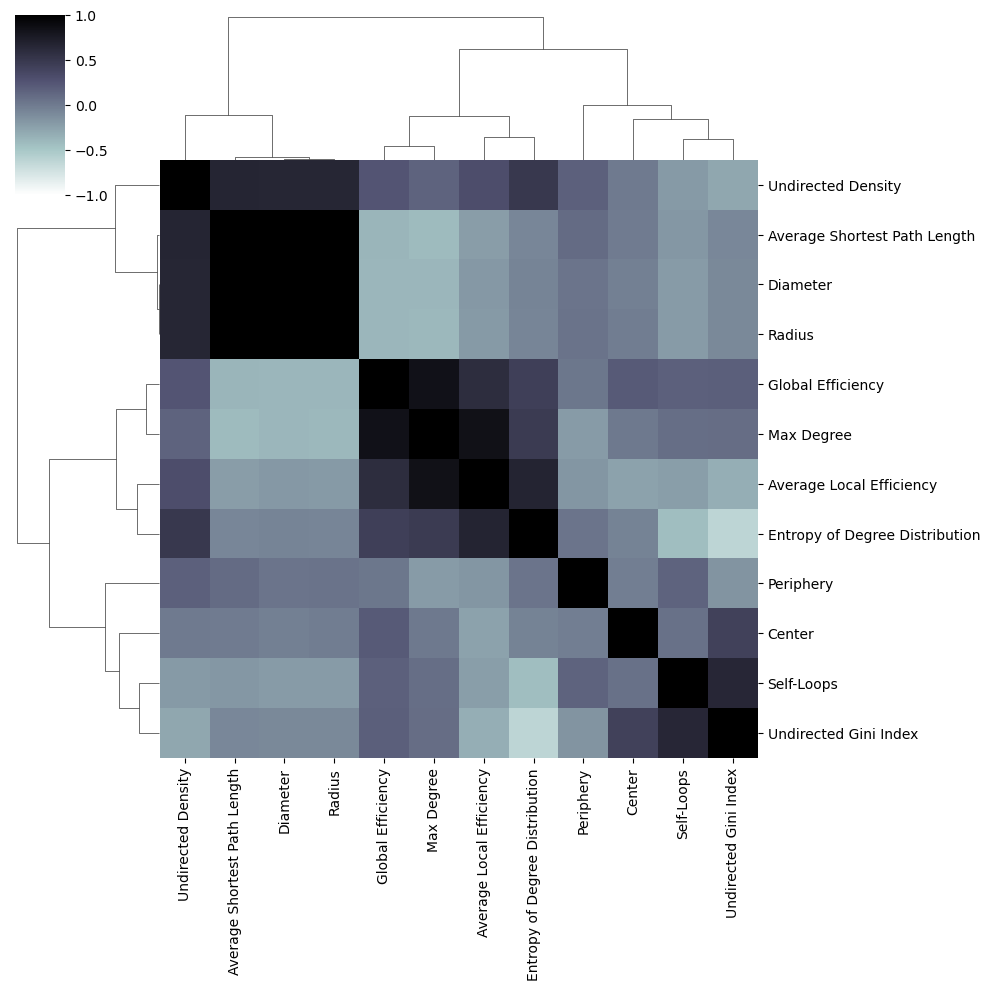

In [8]:
import seaborn as sns
merged_df_corr.dropna(axis=1, how='all', inplace=True)
merged_df_corr.dropna(axis=0, how='all', inplace=True)
ax = sns.clustermap(merged_df_corr,xticklabels=True, yticklabels=True, cmap='bone_r', vmin=-1, vmax=1, method='ward', metric='euclidean')

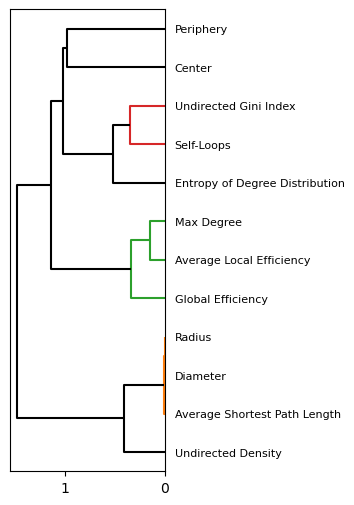

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from netective.utils import get_clusters
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# dist_mtrx = np.sqrt(2*(1 - abs(merged_df_corr.to_numpy())))
dist_mtrx = 1 - abs(merged_df_corr.to_numpy())
condensed_square_matrix = squareform(dist_mtrx)
linkage_mtrx = linkage(condensed_square_matrix, method='ward', metric='euclidean')
index = list(merged_df_corr.index)
relative_max_intracluster_d = linkage_mtrx[:, 2].max()*0.25 # The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2].
cluster_vector = fcluster(linkage_mtrx, criterion="distance", t=relative_max_intracluster_d)
clusters = {i: [] for i in cluster_vector}
[clusters[cluster_vector[i]].append(index[i]) for i in range(len(cluster_vector))];
clusters_with_redundancy = [v for k, v in clusters.items() if len(v) > 1]
clusters_without_redundancy = [v for k, v in clusters.items() if len(v) == 1]
props_without_redundancy = [item for sublist in clusters_without_redundancy for item in sublist]

# plot
plt.figure(figsize=(2, 6))
dendrogram(linkage_mtrx, orientation='left', labels=index, leaf_rotation=0, leaf_font_size=8, color_threshold=relative_max_intracluster_d, above_threshold_color='k');

In [10]:
models = {prefix: i for i, prefix in enumerate(['ba', 'er', 'ws', 'dgm', 'sf'])}

def select_representative_feature(cluster, threshold, correlation_matrix):
    avg_corr_with_others = {}
    for feature1 in cluster:
        # Calculate the average correlation of feature1 with other features in the cluster
        avg_corr = sum([abs(correlation_matrix.loc[feature1, feature2]) for feature2 in cluster if feature1 != feature2]) / (len(cluster) - 1)
        avg_corr_with_others[feature1] = avg_corr

    # Select the feature with the highest average correlation
    representative_feature = max(avg_corr_with_others, key=avg_corr_with_others.get) if max(avg_corr_with_others.values()) >= threshold else None
    return representative_feature
        

        
# Select a threshold for correlation to remove redundant features
threshold = 0.8
distance_score = {}
distance_representative_features = {}
print(f'Features withing the same cluster with a correlation higher than {threshold} will be considered redundant.')
for distance in np.arange(0.05, 0.51, 0.05): # relative_max_intracluster_d
    # dist_mtrx = np.sqrt(2*(1 - abs(merged_df_corr.to_numpy())))
    dist_mtrx = 1 - abs(merged_df_corr.to_numpy())
    condensed_square_matrix = squareform(dist_mtrx)
    linkage_mtrx = linkage(condensed_square_matrix, method='ward', metric='euclidean')
    index = list(merged_df_corr.index)
    relative_max_intracluster_d = linkage_mtrx[:, 2].max()*distance # The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2].
    cluster_vector = fcluster(linkage_mtrx, criterion="distance", t=relative_max_intracluster_d)
    clusters = {i: [] for i in cluster_vector}
    [clusters[cluster_vector[i]].append(index[i]) for i in range(len(cluster_vector))];
    clusters_with_redundancy = [v for k, v in clusters.items() if len(v) > 1]
    clusters_without_redundancy = [v for k, v in clusters.items() if len(v) == 1]
    props_without_redundancy = [item for sublist in clusters_without_redundancy for item in sublist]

    representative_features = props_without_redundancy.copy()
    for cluster in clusters_with_redundancy:
        representative_feature = select_representative_feature(cluster, threshold, merged_df_corr)
        if representative_feature is not None:
            representative_features.append(representative_feature)
        # else: # Ignored so we only keed those features that represent a bunch of features (are more informative?)
        #     representative_features.extend(cluster) # No representative feature was found, so we add all features in the cluster


    sub_corr = merged_df[representative_features].T.corr()
    gs = [models_.get(name.split('_')[0], 4) for name in merged_df.index] # 4 for biological
    clusters = get_clusters(sub_corr, clust_num=5, map_ids=False)

    rand_s = adjusted_rand_score(gs, clusters)
    print(f'max intracluster distance: {distance} with {len(representative_features)} features, {rand_s}')
    distance_score[distance] = rand_s
    distance_representative_features[distance] = representative_features
    

Features withing the same cluster with a correlation higher than 0.8 will be considered redundant.
max intracluster distance: 0.05 with 10 features, 0.6901729752980214
max intracluster distance: 0.1 with 10 features, 0.6901729752980214
max intracluster distance: 0.15000000000000002 with 9 features, 0.7054077311463477
max intracluster distance: 0.2 with 9 features, 0.7054077311463477
max intracluster distance: 0.25 with 6 features, 0.3285239626122185
max intracluster distance: 0.3 with 5 features, 0.3322930008094511
max intracluster distance: 0.35000000000000003 with 5 features, 0.3322930008094511
max intracluster distance: 0.4 with 4 features, 0.23965803464648977
max intracluster distance: 0.45 with 4 features, 0.23965803464648977
max intracluster distance: 0.5 with 4 features, 0.23965803464648977


In [11]:
sub_corr.corr()

,160491_v2015_sRTB13,198466_v2015_sRTB13,186103_v2015_sRTB13,199310_v2015_sRTB13,196620_v2015_sRTB13,158879_v2015_sRTB13,158878_v2015_sRTB13,273036_v2015_sRTB13,100226_v2019_sA22-DBSCR15_eStrong,282458_v2015_sRTB13,...,HM_196627_v2020_s21_eStrong,HM_93062_v2015_sRTB13,BA_511145_v2022_sRDB22_eStrong,ER_511145_v2022_sRDB22_eStrong,SF_511145_v2022_sRDB22_eStrong,BA_83332_v2018_s11-12-15-16,ER_83332_v2018_s11-12-15-16,HM_83332_v2018_s11-12-15-16,HM_511145_v2022_sRDB22_eStrong,SF_83332_v2018_s11-12-15-16
160491_v2015_sRTB13,1.000000,0.998126,0.974691,0.870342,0.749632,0.774885,0.749736,0.748915,0.891199,0.749059,...,0.755106,0.764121,0.948615,-0.704342,0.760694,0.993745,-0.327764,0.755106,0.755106,0.757036
198466_v2015_sRTB13,0.998126,1.000000,0.959236,0.898199,0.788630,0.811919,0.788723,0.787985,0.917157,0.788115,...,0.793639,0.802036,0.965189,-0.675249,0.798814,0.995052,-0.311585,0.793639,0.793639,0.795415
186103_v2015_sRTB13,0.974691,0.959236,1.000000,0.742988,0.584533,0.616454,0.584688,0.583480,0.768959,0.583692,...,0.591807,0.602613,0.859802,-0.776893,0.598722,0.959000,-0.358283,0.591807,0.591807,0.594278
199310_v2015_sRTB13,0.870342,0.898199,0.742988,1.000000,0.975287,0.983906,0.975371,0.974703,0.997663,0.974824,...,0.977921,0.980161,0.980374,-0.338941,0.979665,0.899890,-0.070395,0.977921,0.977921,0.978647
196620_v2015_sRTB13,0.749632,0.788630,0.584533,0.975287,1.000000,0.999046,1.000000,0.999986,0.968188,0.999991,...,0.999854,0.999730,0.913779,-0.203098,0.999732,0.783711,-0.035683,0.999854,0.999854,0.999786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BA_83332_v2018_s11-12-15-16,0.993745,0.995052,0.959000,0.899890,0.783711,0.808869,0.783879,0.782557,0.913346,0.782792,...,0.790185,0.797783,0.968203,-0.622430,0.795438,1.000000,-0.222518,0.790185,0.790185,0.792198
ER_83332_v2018_s11-12-15-16,-0.327764,-0.311585,-0.358283,-0.070395,-0.035683,-0.036428,-0.035081,-0.039762,-0.137345,-0.038915,...,-0.026316,-0.039604,-0.142763,0.842924,-0.029448,-0.222518,1.000000,-0.026316,-0.026316,-0.025527
HM_83332_v2018_s11-12-15-16,0.755106,0.793639,0.591807,0.977921,0.999854,0.999516,0.999867,0.999756,0.970337,0.999778,...,1.000000,0.999874,0.918189,-0.202500,0.999963,0.790185,-0.026316,1.000000,1.000000,0.999993
HM_511145_v2022_sRDB22_eStrong,0.755106,0.793639,0.591807,0.977921,0.999854,0.999516,0.999867,0.999756,0.970337,0.999778,...,1.000000,0.999874,0.918189,-0.202500,0.999963,0.790185,-0.026316,1.000000,1.000000,0.999993


    with 33 props: 0.17219244232781014

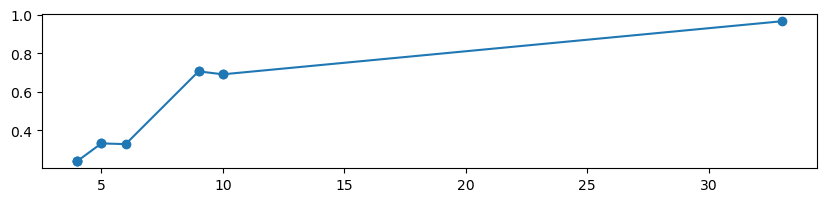

In [12]:
# plot distance vs score as scatter plot and line plot
plt.figure(figsize=(10, 2))
x = [len(x) for x in distance_representative_features.values()]
plt.plot([33]+x, [0.9649169707859021]+list(distance_score.values()), '-o')


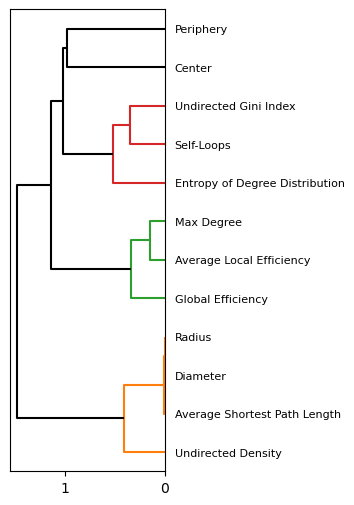

In [13]:
# dist_mtrx = np.sqrt(2*(1 - abs(merged_df_corr.to_numpy())))
dist_mtrx = 1 - abs(merged_df_corr.to_numpy())
condensed_square_matrix = squareform(dist_mtrx)
linkage_mtrx = linkage(condensed_square_matrix, method='ward', metric='euclidean')
index = list(merged_df_corr.index)
relative_max_intracluster_d = linkage_mtrx[:, 2].max()*0.5 # The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2].
cluster_vector = fcluster(linkage_mtrx, criterion="distance", t=relative_max_intracluster_d)
clusters = {i: [] for i in cluster_vector}
[clusters[cluster_vector[i]].append(index[i]) for i in range(len(cluster_vector))];
clusters_with_redundancy = [v for k, v in clusters.items() if len(v) > 1]
clusters_without_redundancy = [v for k, v in clusters.items() if len(v) == 1]
props_without_redundancy = [item for sublist in clusters_without_redundancy for item in sublist]

# plot
plt.figure(figsize=(2, 6))
dendrogram(linkage_mtrx, orientation='left', labels=index, leaf_rotation=0, leaf_font_size=8, color_threshold=relative_max_intracluster_d, above_threshold_color='k');

In [15]:
distance_representative_features[0.2]

['Center',
 'Global Efficiency',
 'Periphery',
 'Entropy of Degree Distribution',
 'Self-Loops',
 'Undirected Gini Index',
 'Undirected Density',
 'Average Local Efficiency',
 'Radius']

In [ ]:
distance_representative_features[0.3]

['Center',
 'Periphery',
 'Complex Feed-Forward Circuits',
 'Feed-Forward Circuits',
 'Max Degree',
 'Radius',
 'Gini Index']

# Edges

In [149]:
with open('edges_0.01_5000.pkl', 'rb') as f:
    edges = pickle.load(f)

type_density_nodes_edges = []
for name, num_edges in edges.items():
    net_type, _, density, num_nodes, _ = name.split('_')
    type_density_nodes_edges.append([net_type, density, num_nodes, num_edges])

In [158]:
df.edges.max()

126143

edges    Axes(0.125,0.11;0.775x0.77)
dtype: object

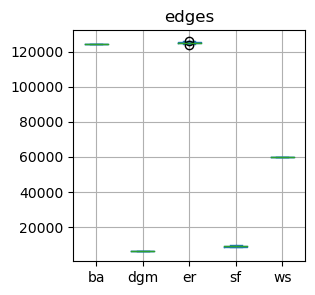

In [168]:
df = pd.DataFrame.from_records(type_density_nodes_edges, columns=['type', 'density', 'nodes', 'edges'], coerce_float=True)
df.plot.box(by='type', column=['edges'], grid=True, figsize=(3,3))

In [188]:
df

,type,density,nodes,edges
0,ba,0.01,5000,124375
1,er,0.01,5000,125192
2,ws,0.01,5000,60000
3,dgm,0.01,5000,6561
4,sf,0.01,5000,8541
...,...,...,...,...
495,ba,0.01,5000,124375
496,er,0.01,5000,125406
497,ws,0.01,5000,60000
498,dgm,0.01,5000,6561


nodes    Axes(0.125,0.11;0.775x0.77)
dtype: object

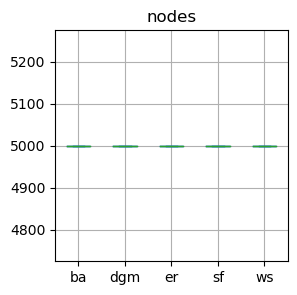

In [176]:
df.nodes = df.nodes.astype(int)
df.plot.box(by='type', column=['nodes'], grid=True, figsize=(3,3))

density    Axes(0.125,0.11;0.775x0.77)
dtype: object

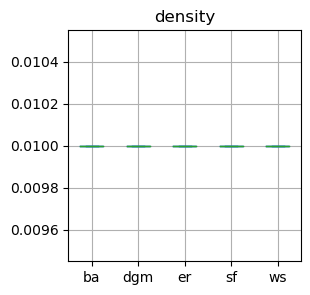

In [185]:
df.density = df.density.astype(float)
df.plot.box(by='type', column=['density'], grid=True, figsize=(3,3))